# Full Dataset

## Imports

In [1]:
import pandas as pd
from prepare_data import *
from data_cleaner import *
from config import *
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)

## Cost

In [2]:
raw_path = API_DATA_DIR / 'raw_responses'
response_path = API_DATA_DIR / 'responses'

In [3]:
files = sorted(raw_path.glob('2026100*'))
cols_to_keep = ['model', 'usage', 'batch_index']
dfs = []

for f in files:
    df_raw = pd.read_json(f, lines=True)[cols_to_keep]
    dfs.append(df_raw)

raw_df = pd.concat(dfs, ignore_index=True)
# unpack usage column
usage_df = pd.json_normalize(raw_df['usage'])
raw_df = pd.concat([raw_df.drop(columns='usage'), usage_df], axis=1)

raw_df.head()

,model,batch_index,completion_tokens,prompt_tokens,total_tokens,reasoning_tokens,cost,completion_tokens_details.accepted_prediction_tokens,completion_tokens_details.audio_tokens,completion_tokens_details.reasoning_tokens,completion_tokens_details.rejected_prediction_tokens,completion_tokens_details.text_tokens,completion_tokens_details.image_tokens,prompt_tokens_details.audio_tokens,prompt_tokens_details.cache_write_tokens,prompt_tokens_details.cached_tokens,prompt_tokens_details.image_tokens,prompt_tokens_details.text_tokens,prompt_tokens_details.video_tokens,prompt_tokens_details.cache_creation_tokens,cost_details.upstream_inference_cost,cost_details.upstream_inference_prompt_cost,cost_details.upstream_inference_completions_cost,cost_details.total_cost,cost_details.input_cost,cost_details.output_cost,cost_details.cached_input_cost,cost_details.cache_write_input_cost,cost_details.request_cost,cost_details.web_search_cost,cost_details.image_input_cost,cost_details.image_output_cost,cost_details.audio_input_cost
0,openai/gpt-5.6-terra,0,4868,105394,110262,3686,0.402503,None,0,3686,None,None,0,0,6598,0,0,None,0,6598.0,0.272503,0.214087,0.058416,0.402503,0.197592,0.058416,0.000000,0.016495,0,0.13,None,None,None
1,openai/gpt-5.6-terra,1,5019,116982,122001,3732,0.415497,None,0,3732,None,None,0,0,1427,5227,0,None,0,1427.0,0.285497,0.225269,0.060228,0.415497,0.220656,0.060228,0.001045,0.003567,0,0.13,None,None,None
2,openai/gpt-5.6-terra,2,5014,116480,121494,3792,0.424388,None,0,3792,None,None,0,0,1338,5227,0,None,0,1338.0,0.284388,0.224220,0.060168,0.424388,0.219830,0.060168,0.001045,0.003345,0,0.14,None,None,None
3,openai/gpt-5.6-terra,3,4414,107708,112122,3133,0.379669,None,0,3133,None,None,0,0,1387,5227,0,None,0,1387.0,0.259669,0.206701,0.052968,0.379669,0.202188,0.052968,0.001045,0.003467,0,0.12,None,None,None
4,openai/gpt-5.6-terra,4,5597,91022,96619,4299,0.340525,None,0,4299,None,None,0,0,1452,5227,0,None,0,1452.0,0.240525,0.173361,0.067164,0.340525,0.168686,0.067164,0.001045,0.003630,0,0.10,None,None,None


In [4]:
price = raw_df.groupby(['model'])['cost'].sum()
t = 0

for model, cost in price.items():
    print("-"*30)
    print(f"Model:   {model}\nCost:    ${cost:.2f}")
    t += cost

print("-"*30)
print(f"Total:   ${t:.2f}")
print("-"*30)

------------------------------
Model:   openai/gpt-5.6-luna
Cost:    $19.10
------------------------------
Model:   openai/gpt-5.6-terra
Cost:    $55.79
------------------------------
Total:   $74.89
------------------------------


# Found rate

In [ ]:
df = get_df(response_path, '2026100*')
df.head()

,model,batch_index,id,name,hasFoundMenu,menuLink,format,source
0,gpt-5.6-terra,0,ChIJ6eXKTWdDUkYR7k5XjV6Ju-0,Ganløse Kro,True,https://ganlosekro.dk/menukort/,HTML,OFFICIAL_WEBSITE
1,gpt-5.6-terra,0,ChIJ21qBwtRDUkYRGBAxnmFfg10,Hjaltes Ganløse,True,https://hjaltesburesoe.dk/wp-content/uploads/2...,PDF,OFFICIAL_WEBSITE
2,gpt-5.6-terra,0,ChIJV5-mcl5DUkYRbdj-CHc26vo,Ganløse Pizzaria & Grillbar,False,,,
3,gpt-5.6-terra,0,ChIJIbl0IgBFUkYRU0k537QppSU,Café Kondi,False,,,
4,gpt-5.6-terra,0,ChIJt4pwV39FUkYRE1tcx-SMAqY,Furesø Madbank,False,,,


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6250 entries, 0 to 6249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   model         6250 non-null   object
 1   batch_index   6250 non-null   int64 
 2   id            6250 non-null   str   
 3   name          6250 non-null   str   
 4   hasFoundMenu  6250 non-null   bool  
 5   menuLink      6250 non-null   str   
 6   format        6250 non-null   str   
 7   source        6250 non-null   str   
dtypes: bool(1), int64(1), object(1), str(5)
memory usage: 915.9+ KB


In [12]:
found_rate = df.groupby('model')['hasFoundMenu'].agg(['sum', 'size'])

for model, row in found_rate.iterrows():
    print("-"*30)
    print(f"Model:   {model}\nFound:   {int(row['sum'])}/{row['size']} ({row['sum'] / row['size']:.1%})")
    print("-"*30)

------------------------------
Model:   gpt-5.6-luna
Found:   2209/3125 (70.7%)
------------------------------
------------------------------
Model:   gpt-5.6-terra
Found:   2389/3125 (76.4%)
------------------------------


## Corporate Chains (where Menu Link was exactly the same)

In [13]:
df.menuLink.replace("", pd.NA).value_counts().head(20)

menuLink
https://www.mcdonalds.com/dk/da-dk/vores-menu.html                                       33
https://jagger.dk/menu/                                                                  23
https://ottopizza.dk/menu/                                                               21
https://www.oliolipoke.dk/menu                                                           18
https://burgerking.dk/menu/view/drinks                                                   17
https://a.storyblok.com/f/286316/x/a7b0fc6a7f/sns-menu-dk-eng-2026-05-210x210-web.pdf    13
https://halifax.dk/menukort/                                                             10
https://www.groed.com/menu                                                               10
https://www.gasolinegrill.com/menu                                                       10
https://jagger.dk/menu/page/2/                                                           10
https://picopizza.dk/menukort/                                         

In [14]:
df.source.value_counts()

source
OFFICIAL_WEBSITE     3476
                     1652
OTHER_THIRD_PARTY     590
WOLT                  432
UBEREATS               99
THE_FORK                1
Name: count, dtype: int64

In [15]:
df.format.value_counts()

format
HTML     3694
         1652
PDF       779
JPEG       75
PNG        37
OTHER      13
Name: count, dtype: int64

## Found Menu

In [16]:
df = df.drop('name', axis=1)
df_full_cph = get_raw_data(RAW_DATA_DIR / 'copenhagen-bounds-full-raw.json')
df_full_cph.head()

,id,name,formattedAddress,primaryType,googleMapsUri,websiteUri,businessStatus,rating,takeout,delivery,dineIn,servesBreakfast,servesLunch,servesDinner,servesBrunch,servesDessert,servesVegetarianFood,priceLevel,startPrice,endPrice,lat,lon
0,ChIJ6eXKTWdDUkYR7k5XjV6Ju-0,Ganløse Kro,"Bygaden 30, 3660 Stenløse, Denmark",restaurant,https://maps.google.com/?cid=17130436646825053...,http://ganlosekro.dk/,OPERATIONAL,4.4,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN,PRICE_LEVEL_MODERATE,200,300,55.793494,12.262844
1,ChIJ21qBwtRDUkYRGBAxnmFfg10,Hjaltes Ganløse,"Bygaden 7, 3660 Stenløse, Denmark",restaurant,https://maps.google.com/?cid=67383343403468759...,http://www.hjaltesburesoe.dk/,OPERATIONAL,4.7,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,PRICE_LEVEL_MODERATE,100,200,55.791115,12.263354
3,ChIJV5-mcl5DUkYRbdj-CHc26vo,Ganløse Pizzaria & Grillbar,"Vestergade 1C, 3660 Stenløse, Denmark",pizza_restaurant,https://maps.google.com/?cid=18080323538912204...,http://ganløse-pizzaria.dk/,OPERATIONAL,4.1,1.0,NaN,1.0,NaN,1.0,1.0,0.0,NaN,NaN,NaN,1,100,55.791086,12.262935
6,ChIJIbl0IgBFUkYRU0k537QppSU,Café Kondi,"Farum Park 20, st. th, 3520 Farum, Denmark",restaurant,https://maps.google.com/?cid=27126202073765174...,NaN,OPERATIONAL,4.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.817371,12.350827
7,ChIJt4pwV39FUkYRE1tcx-SMAqY,Furesø Madbank,"Farum Park 2, 3520 Farum, Denmark",restaurant,https://maps.google.com/?cid=11962278474474609...,NaN,OPERATIONAL,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.815738,12.354581


In [17]:
df_joined = df_full_cph.set_index('id').join(df.set_index('id'))
df_joined.head()

,name,formattedAddress,primaryType,googleMapsUri,websiteUri,businessStatus,rating,takeout,delivery,dineIn,servesBreakfast,servesLunch,servesDinner,servesBrunch,servesDessert,servesVegetarianFood,priceLevel,startPrice,endPrice,lat,lon,model,batch_index,hasFoundMenu,menuLink,format,source
id,,,,,,,,,,,,,,,,,,,,,,,,,,,
ChIJ6eXKTWdDUkYR7k5XjV6Ju-0,Ganløse Kro,"Bygaden 30, 3660 Stenløse, Denmark",restaurant,https://maps.google.com/?cid=17130436646825053...,http://ganlosekro.dk/,OPERATIONAL,4.4,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN,PRICE_LEVEL_MODERATE,200,300,55.793494,12.262844,gpt-5.6-terra,0,True,https://ganlosekro.dk/menukort/,HTML,OFFICIAL_WEBSITE
ChIJ6eXKTWdDUkYR7k5XjV6Ju-0,Ganløse Kro,"Bygaden 30, 3660 Stenløse, Denmark",restaurant,https://maps.google.com/?cid=17130436646825053...,http://ganlosekro.dk/,OPERATIONAL,4.4,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN,PRICE_LEVEL_MODERATE,200,300,55.793494,12.262844,gpt-5.6-luna,0,True,https://ganlosekro.dk/menukort/,HTML,OFFICIAL_WEBSITE
ChIJ21qBwtRDUkYRGBAxnmFfg10,Hjaltes Ganløse,"Bygaden 7, 3660 Stenløse, Denmark",restaurant,https://maps.google.com/?cid=67383343403468759...,http://www.hjaltesburesoe.dk/,OPERATIONAL,4.7,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,PRICE_LEVEL_MODERATE,100,200,55.791115,12.263354,gpt-5.6-terra,0,True,https://hjaltesburesoe.dk/wp-content/uploads/2...,PDF,OFFICIAL_WEBSITE
ChIJ21qBwtRDUkYRGBAxnmFfg10,Hjaltes Ganløse,"Bygaden 7, 3660 Stenløse, Denmark",restaurant,https://maps.google.com/?cid=67383343403468759...,http://www.hjaltesburesoe.dk/,OPERATIONAL,4.7,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,PRICE_LEVEL_MODERATE,100,200,55.791115,12.263354,gpt-5.6-luna,0,True,https://hjaltesburesoe.dk/wp-content/uploads/2...,PDF,OFFICIAL_WEBSITE
ChIJV5-mcl5DUkYRbdj-CHc26vo,Ganløse Pizzaria & Grillbar,"Vestergade 1C, 3660 Stenløse, Denmark",pizza_restaurant,https://maps.google.com/?cid=18080323538912204...,http://ganløse-pizzaria.dk/,OPERATIONAL,4.1,1.0,NaN,1.0,NaN,1.0,1.0,0.0,NaN,NaN,NaN,1,100,55.791086,12.262935,gpt-5.6-terra,0,False,,,


## Plot

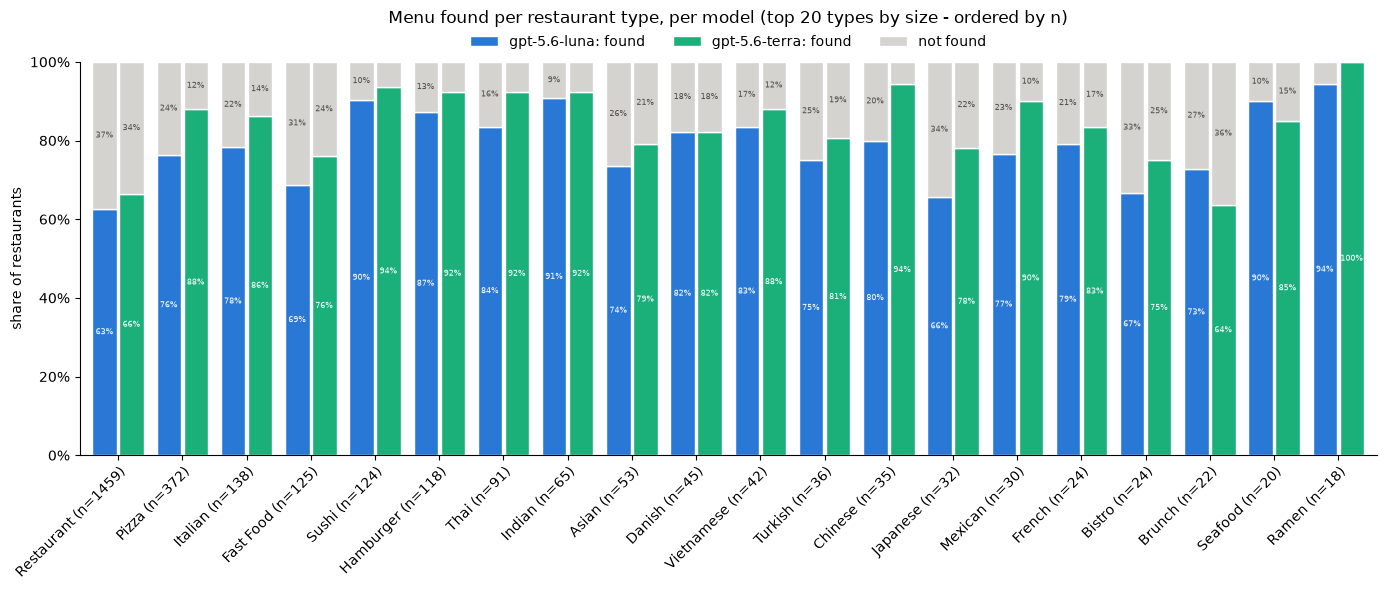

In [18]:
plot_df = df_joined.reset_index()   # id is duplicated (one row per model)
models = sorted(plot_df["model"].unique())

# share of found / not found per type and model (each row sums to 100%)
shares = pd.crosstab([plot_df["primaryType"], plot_df["model"]], plot_df["hasFoundMenu"], normalize="index") * 100
shares = shares.reindex(columns=[True, False], fill_value=0)
n_per_type = plot_df.groupby("primaryType")["id"].nunique()

# 20 largest types, ordered by size (largest on the left)
order = n_per_type.sort_values(ascending=False).head(20).index

found_colors = {"gpt-5.6-luna": "#2a78d6", "gpt-5.6-terra": "#1baf7a"}
not_found_color = "#d4d3cf"
width = 0.38    # each bar of the pair
gap = 0.04      # space between the paired bars
x = np.arange(len(order))

fig, ax = plt.subplots(figsize=(0.6 * len(order) + 2, 6))

for i, model in enumerate(models):
    offset = (i - 0.5) * (width + gap)   # first model left, second right
    plot = shares.xs(model, level="model").loc[order]
    bottom = np.zeros(len(order))
    for found in [True, False]:
        color = found_colors[model] if found else not_found_color
        label = f"{model}: found" if found else ("not found" if i == 0 else None)
        bars = ax.bar(x + offset, plot[found], bottom=bottom, width=width, color=color,
                       edgecolor="white", linewidth=1, label=label)
        ax.bar_label(bars, labels=[f"{v:.0f}%" if v >= 8 else "" for v in plot[found]],
                     label_type="center", fontsize=6, color="white" if found else "#52514e")
        bottom += plot[found].values

ax.set_xticks(x)
pretty = lambda t: t.removesuffix("_restaurant").replace("_", " ").title()   # fast_food_restaurant -> Fast Food
ax.set_xticklabels([f"{pretty(t)} (n={n_per_type[t]})" for t in order], rotation=45, ha="right", rotation_mode="anchor")
ax.set_ylim(0, 100)
ax.set_xlim(-0.6, len(order) - 0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_ylabel("share of restaurants")
ax.set_title("Menu found per restaurant type, per model (top 20 types by size - ordered by n)", pad=28)   # room for the legend below the title
handles, labels = ax.get_legend_handles_labels()
legend_order = [0, 2, 1]   # luna, terra, not found
ax.legend([handles[i] for i in legend_order], [labels[i] for i in legend_order], frameon=False, ncols=3, loc="lower center", bbox_to_anchor=(0.5, 1.0))
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [19]:
print(f"There are in total {len(df_joined.primaryType.unique())} primary restaurant types")
print(f"{(n_per_type <= 10).sum()}/{len(df_joined.primaryType.unique())} have n <= 10 ")

There are in total 78 primary restaurant types
53/78 have n <= 10 


## Model Comparison: gpt-5.6-terra vs gpt-5.6-luna

Both models were run on the same 3125 restaurants (terra: `20261001-133048`, luna: `20261002-094032`.

### Cost and Token Usage

In [20]:
model_name = raw_df['model'].str.split('/').str[1]

usage = raw_df.groupby(model_name).agg(
    batches=('batch_index', 'size'),
    cost=('cost', 'sum'),
    prompt_tokens=('prompt_tokens', 'sum'),
    cached_tokens=('prompt_tokens_details.cached_tokens', 'sum'),
    completion_tokens=('completion_tokens', 'sum'),
    reasoning_tokens=('reasoning_tokens', 'sum'),
)
usage['cost_per_restaurant'] = usage['cost'] / df.groupby('model').size()
usage['cost_per_found_menu'] = usage['cost'] / df.groupby('model')['hasFoundMenu'].sum()
usage['prompt_tokens_per_batch'] = usage['prompt_tokens'] / usage['batches']
usage['cached_share'] = usage['cached_tokens'] / usage['prompt_tokens']
usage['reasoning_share'] = usage['reasoning_tokens'] / usage['completion_tokens']

usage.round(4)

,batches,cost,prompt_tokens,cached_tokens,completion_tokens,reasoning_tokens,cost_per_restaurant,cost_per_found_menu,prompt_tokens_per_batch,cached_share,reasoning_share
model,,,,,,,,,,,
gpt-5.6-luna,157,19.1040,12363653,818159,506257,297086,0.0061,0.0086,78749.3822,0.0662,0.5868
gpt-5.6-terra,157,55.7905,15123656,811609,713399,522318,0.0179,0.0234,96329.0191,0.0537,0.7322


In [21]:
# what the money is spent on
cost_parts = {
    'input': ['cost_details.input_cost', 'cost_details.cached_input_cost', 'cost_details.cache_write_input_cost'],
    'output': ['cost_details.output_cost'],
    'web search': ['cost_details.web_search_cost'],
}
cost_breakdown = pd.DataFrame({part: raw_df[cols].sum(axis=1) for part, cols in cost_parts.items()}).groupby(model_name).sum()
cost_share = cost_breakdown.div(cost_breakdown.sum(axis=1), axis=0)

pd.concat({'cost ($)': cost_breakdown.round(2), 'share': cost_share.round(3)}, axis=1)

cost ($)                    share                  
                 input output web search  input output web search
model                                                            
gpt-5.6-luna      2.34   0.61      16.16  0.122  0.032      0.846
gpt-5.6-terra    28.90   8.56      18.33  0.518  0.153      0.329

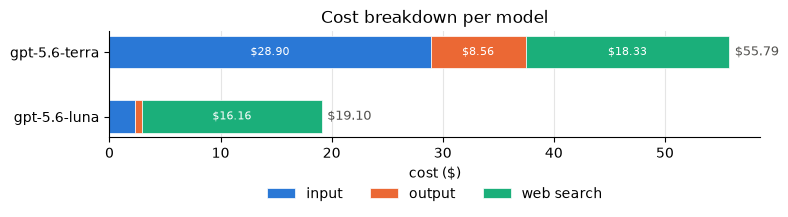

In [22]:
colors = {'input': '#2a78d6', 'output': '#eb6834', 'web search': '#1baf7a'}

fig, ax = plt.subplots(figsize=(8, 2.6))
left = np.zeros(len(cost_breakdown))

for part, color in colors.items():
    bars = ax.barh(cost_breakdown.index, cost_breakdown[part], left=left, height=0.5,
                   color=color, edgecolor='white', linewidth=0.5, label=part)
    ax.bar_label(bars, labels=[f"${v:.2f}" if v > 5 else "" for v in cost_breakdown[part]],
                 label_type='center', fontsize=8, color='white')
    left += cost_breakdown[part].values

for y, total in enumerate(left):
    ax.text(total + 0.5, y, f"${total:.2f}", va='center', fontsize=9, color='#52514e')

ax.set_xlabel('cost ($)')
ax.set_title('Cost breakdown per model')
ax.legend(frameon=False, ncols=3, loc='upper center', bbox_to_anchor=(0.5, -0.35))
ax.grid(axis='x', color='#e5e5e5')
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Agreement on hasFoundMenu

- Out of 3125 restaurants, the models fully agree on whether or not there was a menu to be found for 2707 restaurants.
  - 2090 of them are cases, where the models agree that *they found a menu* (`hasFoundMenu` = true)
  - 617 of them are cases, where the models agree that *they did not find a menu* (`hasFoundMenu` = false)
- Percentage wise this is an agreement of 86.6%, and taking randomized luck into account we have a Cohen's kappa of 0.658

In [23]:
from sklearn.metrics import cohen_kappa_score

found = df.pivot(index='id', columns='model', values='hasFoundMenu').astype(bool)
terra_found, luna_found = found['gpt-5.6-terra'], found['gpt-5.6-luna']

agree = terra_found == luna_found
print(f"[hasFoundMenu] % agreement: {agree.sum()}/{len(found)} restaurants ({agree.mean():.1%})")
print(f"Cohen's kappa:              {cohen_kappa_score(terra_found, luna_found):.3f}")

pd.crosstab(terra_found, luna_found, rownames=['terra'], colnames=['luna'], margins=True)

[hasFoundMenu] % agreement: 2707/3125 restaurants (86.6%)
Cohen's kappa:              0.658


luna,False,True,All
terra,,,
False,617,119,736
True,299,2090,2389
All,916,2209,3125


### Agreement on menuLink

- Out of the 2707, 2090 restaurants were entries where both models said there was a menu to be found (`hasFoundMenu` = true)
- When we look at those 2090 restaurants, 1010 (48.3%) of them are exactly the same, after normalizing the URLs using `trim_urls`.
- 1080 restaurants are left where the models found different links
- 418 (119 + 299) restaurants are left where the models disagree on if there was a menu or not.

In [24]:
from data_cleaner import trim_urls

links = trim_urls(df.copy()).pivot(index='id', columns='model', values='normalized_urls')
both_found = found.all(axis=1)
terra_url = links.loc[both_found, 'gpt-5.6-terra']
luna_url = links.loc[both_found, 'gpt-5.6-luna']

same_url = terra_url == luna_url

print(f"Both models found a menu for {both_found.sum()} restaurants")
print(f"Same menu link: {same_url.sum()}/{both_found.sum()} ({same_url.mean():.1%})")

Both models found a menu for 2090 restaurants
Same menu link: 1010/2090 (48.3%)


In [25]:
# which sources the models used when their links differ
sources = df.pivot(index='id', columns='model', values='source').loc[both_found]
different = sources[~same_url]
pd.crosstab(different['gpt-5.6-terra'], different['gpt-5.6-luna'], rownames=['terra'], colnames=['luna'], margins=True)

luna,OFFICIAL_WEBSITE,OTHER_THIRD_PARTY,UBEREATS,WOLT,All
terra,,,,,
OFFICIAL_WEBSITE,639,74,12,58,783
OTHER_THIRD_PARTY,68,35,4,21,128
UBEREATS,15,1,3,9,28
WOLT,66,29,13,33,141
All,788,139,32,121,1080


In [26]:
# examples of different links
pd.DataFrame({'terra': terra_url[~same_url], 'luna': luna_url[~same_url]}).head(20)

,terra,luna
id,,
ChIJ-3xQ-_lTUkYRSnuyg4QIraQ,media.radissonhotels.net/asset/radisson-collec...,radissonhotels.iceportal.com/image/radisson-co...
ChIJ-41YxJ1TUkYRrVaOWtyYtco,ramenhokkaido.dk/elementor-2438,ramenhokkaido.orderyoyo.com/ramen-hokkaido-sol...
ChIJ-5oIomZTUkYR_DlSy3g3m2I,zendimsumsushi.dk/images/Zendimsun_2025_nytar_...,zendimsumsushi.dk/take-away
ChIJ-6y2dr1TUkYRzkHv0OuQUag,wolt.com/en/dnk/copenhagen/restaurant/gao-dump...,gaodumpling.com
ChIJ-9mCCwBVUkYRGtEPQ3c9ieA,wok.dk/da/homepage,wok.dk/Assets/pdf/eng_ver2.pdf
ChIJ-9mp_qhNUkYRxtgWI6HFfI0,fortunen.nu/wp-content/uploads/2026/09/FORTUNE...,fortunen.nu/wp-content/uploads/2026/09/Fortune...
ChIJ-RVpWABTUkYRldJfT-_MxVQ,wolt.com/en/dnk/copenhagen/restaurant/banh-mi-cph,wolt.com/da/dnk/copenhagen/restaurant/banh-mi-...
ChIJ-Re5yHlTUkYRZiXIv-chOfU,pokeandsons.com,pokeandsons.com/en
ChIJ-Sw5dpxTUkYR1iQernmhu1k,restaurantmaison.dk/menu-1,weur-cdn.menukort.menu/storage/media/companies...


**Findings**

*Cost and token usage*
- terra cost **\$55.79** and luna **\$19.10**, so luna is about 2.9× cheaper: \$0.018 vs \$0.006 per restaurant, or \$0.023 vs \$0.009 per found menu.
- **Web search is the biggest cost for luna** (\$16.16, 85% of its cost) and a third of terra's (\$18.33, 33%). Both models search a similar amount, so the price difference comes from the model itself: terra's input tokens cost \$28.90 vs luna's \$2.34.
- Prompt tokens are ~96k (terra) and ~79k (luna) per batch, although the system prompt and 20 restaurants are only a few thousand tokens. Most of the prompt tokens are probably web search results fed back to the model.
- Caching only covers the system prompt (~5.2k tokens per batch), about 5–7% of prompt tokens, so it barely affects cost.
- terra reasons more: 73% of its completion tokens are reasoning, vs 59% for luna.

*hasFoundMenu*
- The models agree on **86.6%** of restaurants (2707/3125), Cohen's kappa **0.658** (substantial agreement).
- When they disagree, it's mostly terra finding a menu that luna didn't (299) rather than the other way around (119).

*menuLink*
- Both found a menu for 2090 restaurants. Only **48.3%** (1010) have the exact same link, but **76.6%** (1600) are on the same domain.
- In 639 of the 1080 different links, both models used the restaurant's official website but picked a different page -- e.g. a `/menu` page vs a PDF, or a lunch vs a dinner menu. The rest mostly differ in official website vs a third party like Wolt.
- So a different link doesn't necessarily mean one of them is wrong -- checking that needs manual annotation.

# Manual Verification

Since 1010 of the menulinks found were **exactly the same link** I will accept that solution.
I will select 100 - 200 menulinks that are not exactly the same and I will do manual verification on them.

- Create an Annotation Codebook to ensure how to label them
- Start annotating

In [27]:
diff_links = links[links['gpt-5.6-luna'] != links['gpt-5.6-terra']]
diff_links

model,gpt-5.6-luna,gpt-5.6-terra
id,,
ChIJ-1BtnEpTUkYR0V70h9EWKRo,wolt.com/da/dnk/copenhagen/restaurant/the-vill...,
ChIJ-3xQ-_lTUkYRSnuyg4QIraQ,radissonhotels.iceportal.com/image/radisson-co...,media.radissonhotels.net/asset/radisson-collec...
ChIJ-41YxJ1TUkYRrVaOWtyYtco,ramenhokkaido.orderyoyo.com/ramen-hokkaido-sol...,ramenhokkaido.dk/elementor-2438
ChIJ-55H0hlTUkYR9uLE_ttm8U0,,wokshop.dk/restaurant/wokshop-koebenhavn-wokshop
ChIJ-5oIomZTUkYR_DlSy3g3m2I,zendimsumsushi.dk/take-away,zendimsumsushi.dk/images/Zendimsun_2025_nytar_...
...,...,...
ChIJzfRF-2NVUkYRVsZU3pdq7zs,,hubnordic.madkastel.dk/menu
ChIJzfaHX29PUkYRwjta4NqWd2E,caferoomies.dk,
ChIJzwHqOcVaUkYRSIu6qfujeUk,ladyvagabonden-ballerup.dk,ladyogvagabonden.dk/menu


In [28]:
# restaurants where the models disagree on the link, with the original (clickable) links, for annotation
raw_links = df.pivot(index='id', columns='model', values='menuLink').loc[diff_links.index]
restaurant_info = df_full_cph.drop_duplicates('id').set_index('id')[['name', 'googleMapsUri']]

to_annotate = restaurant_info.join(raw_links, how='inner').reset_index()
to_annotate = to_annotate[['id', 'name', 'googleMapsUri', 'gpt-5.6-luna', 'gpt-5.6-terra']]
to_annotate.to_csv(API_DATA_DIR / 'disagreement_links_to_annotate.csv', index=False)

print(f"{len(to_annotate)} restaurants saved to {API_DATA_DIR / 'disagreement_links_to_annotate.csv'}")
to_annotate.head()

1498 restaurants saved to /Users/rakul/Desktop/cs/5sem/msc/cph-menu-finder/data/api_runs/disagreement_links_to_annotate.csv


,id,name,googleMapsUri,gpt-5.6-luna,gpt-5.6-terra
0,ChIJw0c3oxlbUkYRRaRIK9Zyl64,Måløv Kebab,https://maps.google.com/?cid=12580650348257518...,,https://semeny.no/dk/sted/maloevkebab
1,ChIJ_40QkdhaUkYRZd5nIBlledk,Måløv Hus Pizzaria & Grill,https://maps.google.com/?cid=15670667537004617...,https://malovpizza.dk/,https://www.meal4u.dk/restaurants/2760-malov/4...
2,ChIJW7q27NhaUkYRDIeOJO4L2G8,Måløv Sushi & Wok,https://maps.google.com/?cid=80592046506229450...,https://maalovsushiogwok.dk/,https://www.xn--mlvsushi-9za5q.dk/take-away
3,ChIJzwHqOcVaUkYRSIu6qfujeUk,Lady & Vagabonden,https://maps.google.com/?cid=52944431382304223...,https://ladyvagabonden-ballerup.dk/,https://www.ladyogvagabonden.dk/menu
4,ChIJDUItdSxFUkYRDJ9eDe3LSJc,Koriander,https://maps.google.com/?cid=10901187117042278...,,https://www.koriandertakeaway-3520.dk/
